In [ ]:
### load the regenerated masks, 1G for one sample 
import nibabel as nib
#load in the mask file
mask = nib.load('xxx').get_fdata()
#load in the post file, after softmax
mask_post = nib.load('xxx').get_fdata()
#load in the post file before softmax
smask_post = nib.load('xxx').get_fdata()
#load in the parc mask file before softmax
smask_parc = nib.load('xxx').get_fdata()

In [17]:
#print the shape of the post file
print(f'post.shape: {mask_post.shape}')
print(f'mask.shape: {mask.shape}')
print(f'smask_post.shape: {smask_post.shape}')
print(f'smask_parc.shape: {smask_parc.shape}')

post.shape: (138, 176, 138, 33)
mask.shape: (138, 176, 138)
smask_post.shape: (138, 176, 138, 33)
smask_parc.shape: (138, 176, 138, 69)


In [1]:
#This is for the binary mask
region_labels = {
    'cingulate': [
        1002, 1010, 1023, 1026,  # Left caudal anterior, isthmus, posterior, rostral anterior
        2002, 2010, 2023, 2026   # Right caudal anterior, isthmus, posterior, rostral anterior
    ],
    
    'frontal': [1003, 1012, 1014, 1018, 1019, 1020, 1024, 1027, 1028, 1032, 2003, 2012, 2014, 2018, 2019, 2020, 2024, 2027, 2028, 2032],
    
    'parietal': [
        1008, 1009, 1022, 1025, 1029, 1031,  # Left parietal regions
        2008, 2009, 2022, 2025, 2029, 2031   # Right parietal regions
    ],
    
    'temporal': [
        1001, 1004, 1005, 1006, 1007, 1013, 1030, 1033, 1034,  # Left temporal regions
        2001, 2004, 2005, 2006, 2007, 2013, 2030, 2033, 2034   # Right temporal regions
    ],
    
    'occipital': [
        1011, 1015, 1017, 1021,  # Left occipital regions
        2011, 2015, 2017, 2021   # Right occipital regions
    ],
    
    'insular': [
        1035,  # Left insula
        2035   # Right insula
    ]
}

# Verify total count
total = sum(len(labels) for labels in region_labels.values())
print(f"Total number of regions: {total}")
print(f"Number of unique regions per hemisphere: {total//2}")

# The total should be 68 regions (34 per hemisphere)

Total number of regions: 68
Number of unique regions per hemisphere: 34


In [19]:
# this is for the logit mask, find their index from their binary index

a = [0, 1001, 1002, 1003, 1005, 1006, 1007, 1008, 1009, 1010, 1011, 1012, 1013, 1014,
              1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028,
              1029, 1030, 1031, 1032, 1033, 1034, 1035, 2001, 2002, 2003, 2005, 2006, 2007, 2008,
              2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
              2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035]
print(len(a))
#make a dictionary to map the label to the roi index, here like0:0, 1001:1, 1002: 2, 1005: 4    
label_to_roi = {label: index for index, label in enumerate(a)}
print(label_to_roi)

69
{0: 0, 1001: 1, 1002: 2, 1003: 3, 1005: 4, 1006: 5, 1007: 6, 1008: 7, 1009: 8, 1010: 9, 1011: 10, 1012: 11, 1013: 12, 1014: 13, 1015: 14, 1016: 15, 1017: 16, 1018: 17, 1019: 18, 1020: 19, 1021: 20, 1022: 21, 1023: 22, 1024: 23, 1025: 24, 1026: 25, 1027: 26, 1028: 27, 1029: 28, 1030: 29, 1031: 30, 1032: 31, 1033: 32, 1034: 33, 1035: 34, 2001: 35, 2002: 36, 2003: 37, 2005: 38, 2006: 39, 2007: 40, 2008: 41, 2009: 42, 2010: 43, 2011: 44, 2012: 45, 2013: 46, 2014: 47, 2015: 48, 2016: 49, 2017: 50, 2018: 51, 2019: 52, 2020: 53, 2021: 54, 2022: 55, 2023: 56, 2024: 57, 2025: 58, 2026: 59, 2027: 60, 2028: 61, 2029: 62, 2030: 63, 2031: 64, 2032: 65, 2033: 66, 2034: 67, 2035: 68}


In [20]:
### This is for subcortex, e.g., CSF, White matter
sub_index_to_label = {
    0: 0,    # Background
    1: 2,    # Left Cerebral White Matter
    2: 3,    # Left Cerebral Cortex
    3: 4,    # Left Lateral Ventricle
    4: 5,    # Left Inferior Lateral Ventricle
    5: 7,    # Left Cerebellum White Matter
    6: 8,    # Left Cerebellum Cortex
    7: 10,   # Left Thalamus
    8: 11,   # Left Caudate
    9: 12,   # Left Putamen
    10: 13,  # Left Pallidum
    11: 14,  # 3rd Ventricle
    12: 15,  # 4th Ventricle
    13: 16,  # Brain Stem
    14: 17,  # Left Hippocampus
    15: 18,  # Left Amygdala
    16: 24,  # CSF
    17: 26,  # Left Accumbens
    18: 28,  # Left Ventral DC
    19: 41,  # Right Cerebral White Matter
    20: 42,  # Right Cerebral Cortex
    21: 43,  # Right Lateral Ventricle
    22: 44,  # Right Inferior Lateral Ventricle
    23: 46,  # Right Cerebellum White Matter
    24: 47,  # Right Cerebellum Cortex
    25: 49,  # Right Thalamus
    26: 50,  # Right Caudate
    27: 51,  # Right Putamen
    28: 52,  # Right Pallidum
    29: 53,  # Right Hippocampus
    30: 54,  # Right Amygdala
    31: 58,  # Right Accumbens
    32: 60   # Right Ventral DC
}



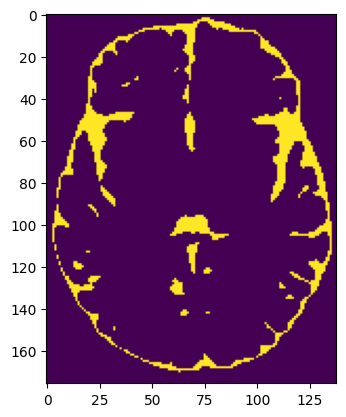

In [21]:
import matplotlib.pyplot as plt
import numpy as np
## take CSF and visualize it, mask is 24, smask_post is 16
csf_mask = np.where((mask == 24), 1, 0).astype(np.float32)
# take slice 66, and rotate it 90 degrees
csf_mask1 = np.rot90(csf_mask[:,:,66])
plt.imshow(csf_mask1)
# save the csf mask
# nib.save(nib.Nifti1Image(csf_mask1, affine=np.eye(4)), '/home/wepeng/binx/test_masks/csf_mask.nii.gz')


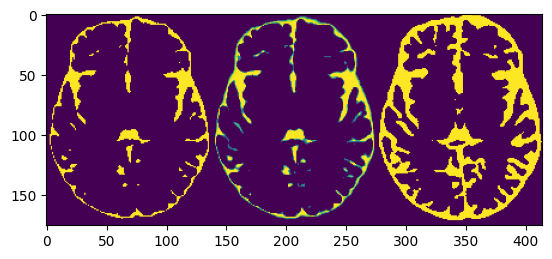

In [9]:
# Get CSF masks from post and smask_post, post is after softmax
csf_mask2 = mask_post[..., 16]

csf_probs = np.where(smask_post[...,16]>0.01, 1, 0).astype(np.float32)
#concat them and plot the csf_probs
csf_mask_v = np.concatenate((csf_mask1, np.rot90(csf_mask2[...,66]), np.rot90(csf_probs[...,66])), axis=-1)
plt.imshow(csf_mask_v)


(138, 176, 138)


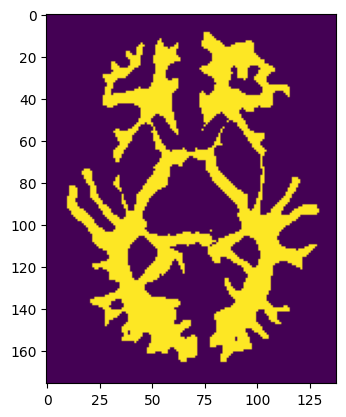

In [10]:
## Get the white matter from the mask, mask is 2, 7, 41, 46,
wm_label = [2, 7, 41, 46]
wm_mask = np.isin(mask, wm_label).astype(np.float32)
print(wm_mask.shape)
# # take slice 66, and rotate it 90 degrees
wm_mask1 = np.rot90(wm_mask[:,:,66])
plt.imshow(wm_mask1)
# nib.save(nib.Nifti1Image(wm_mask, affine=np.eye(4)), '/home/wepeng/binx/test_masks/wm_mask.nii.gz')


[3, 11, 13, 17, 18, 19, 23, 26, 27, 31, 37, 45, 47, 51, 52, 53, 57, 60, 61, 65]
[1003, 1012, 1014, 1018, 1019, 1020, 1024, 1027, 1028, 1032, 2003, 2012, 2014, 2018, 2019, 2020, 2024, 2027, 2028, 2032]


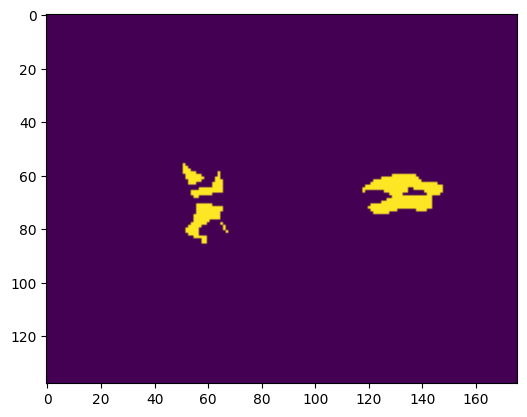

In [145]:
## get the frontal index from the label_to_roi
frontal_index = [label_to_roi[label] for label in region_labels['frontal']]
print(frontal_index)
print(region_labels['frontal'])
# Get the frontal mask and frontal problibilities 
frontal_mask = np.zeros_like(mask)
frontal_mask = np.isin(mask, region_labels['frontal']).astype(np.float32)
cingulate_mask = np.zeros_like(mask)
cingulate_mask = np.isin(mask, region_labels['cingulate']).astype(np.float32)
# for label in region_labels['frontal']:
#     frontal_mask += np.where(mask == label, 1, 0)
frontal_probs =np.where((smask_parc[..., frontal_index]>0.2), 1, 0).astype(np.float32)


# merge frontal_probs to one channel
frontal_probs = np.sum(frontal_probs, axis=-1)
## could be frontal_probs get several 1 for the same location from several sub-frontal ROIs
frontal_probs =np.where((frontal_probs>1), 1, frontal_probs).astype(np.float32)

#concat and plot the frontal_probs
index = 64
frontal_probs = np.concatenate((frontal_mask[:,:,index], frontal_probs[:,:,index]), axis=-1)
# frontal_probs = np.concatenate((frontal_mask[:,:,index], frontal_probs[:,:,index]), axis=-1)
plt.imshow(frontal_probs)
plt.imshow(cingulate_mask[:,:,66])
# nib.save(nib.Nifti1Image(csf_probs, affine=np.eye(4)), '/home/wepeng/binx/test_masks/1_csf_mask.nii.gz')
# nib.save(nib.Nifti1Image(frontal_mask, affine=np.eye(4)), '/home/wepeng/binx/test_masks/1_frontal_mask.nii.gz')
# nib.save(nib.Nifti1Image(frontal_probs, affine=np.eye(4)), '/home/wepeng/binx/test_masks/1_frontal_probs.nii.gz')


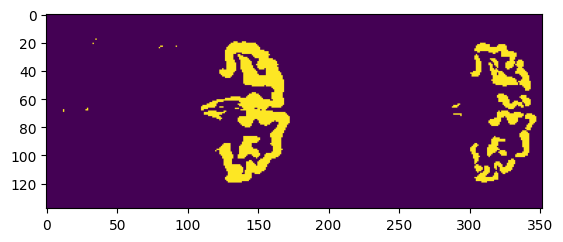

In [23]:
## change the thresholds of the frontal_probs to check the differences
frontal_probs =np.where((smask_parc[..., frontal_index]>0.1), 1, 0).astype(np.float32)
frontal_probs2 =np.where((smask_parc[..., frontal_index]>0.7), 1, 0).astype(np.float32)
frontal_probs = np.sum(frontal_probs, axis=-1)
frontal_probs2 = np.sum(frontal_probs2, axis=-1)
frontal_probs =np.where((frontal_probs>1), 1, frontal_probs).astype(np.float32)
frontal_probs2 =np.where((frontal_probs2>1), 1, frontal_probs2).astype(np.float32)


#concat and plot the frontal_probs2
frontal_probs2 = np.concatenate((frontal_probs[:,:,66], frontal_probs2[:,:,66]), axis=-1)
plt.imshow(frontal_probs2)


In [24]:
## compute the number of the frontal voxels
num_frontal_voxels = np.sum(frontal_mask)
print(f'num_frontal_voxels: {num_frontal_voxels}')
## compute the number of the frontal voxels after threshold
num_frontal_voxels_new = np.sum(frontal_probs)
print(f'num_frontal_voxels_new: {num_frontal_voxels_new}')
## compute the percentage increase
percentage_increase = (num_frontal_voxels_new-num_frontal_voxels)/num_frontal_voxels
print(f'Percentage increase: {100*percentage_increase:0.01f}%')


num_frontal_voxels: 164943.0
num_frontal_voxels_new: 234587.0
Percentage increase: 42.2%


[7, 8, 21, 24, 28, 30, 41, 42, 55, 58, 62, 64]
[1008, 1009, 1022, 1025, 1029, 1031, 2008, 2009, 2022, 2025, 2029, 2031]


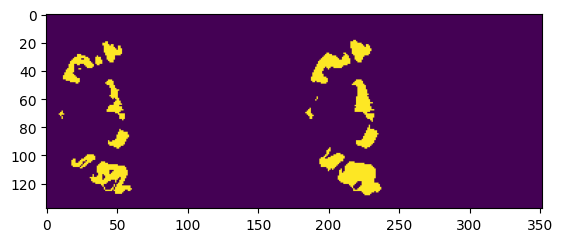

In [25]:
## get the parietal index from the label_to_roi
parietal_index = [label_to_roi[label] for label in region_labels['parietal']]
# Get the parietal mask and parietal problibilities 
print(parietal_index)
print(region_labels['parietal'])
parietal_mask = np.isin(mask, region_labels['parietal']).astype(np.float32)

parietal_probs =np.where((smask_parc[..., parietal_index]>0.2), 1, 0).astype(np.float32)


# merge frontal_probs to one channel
parietal_probs = np.sum(parietal_probs, axis=-1)
parietal_probs =np.where((parietal_probs>1), 1, parietal_probs).astype(np.float32)

#concat and plot the frontal_probs
parietal_probs = np.concatenate((parietal_mask[:,:,66], parietal_probs[:,:,66]), axis=-1)
plt.imshow(parietal_probs)

# nib.save(nib.Nifti1Image(csf_probs, affine=np.eye(4)), '/home/wepeng/binx/test_masks/1_csf_mask.nii.gz')
# nib.save(nib.Nifti1Image(frontal_mask, affine=np.eye(4)), '/home/wepeng/binx/test_masks/1_frontal_mask.nii.gz')
# nib.save(nib.Nifti1Image(frontal_probs, affine=np.eye(4)), '/home/wepeng/binx/test_masks/1_frontal_probs.nii.gz')


[1035, 2035]
[34, 68]


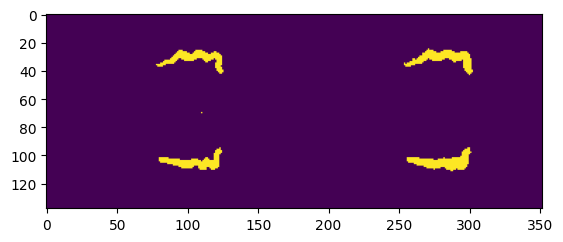

In [26]:
## get the insular index from the label_to_roi
insular_index = [label_to_roi[label] for label in region_labels['insular']]
# Get the insular mask and insular problibilities 
insular_mask = np.isin(mask, region_labels['insular']).astype(np.float32)
print(region_labels['insular'])
print(insular_index)
insular_probs =np.where((smask_parc[..., insular_index]>0.2), 1, 0).astype(np.float32)


# merge insular_probs to one channel
insular_probs = np.sum(insular_probs, axis=-1)
insular_probs =np.where((insular_probs>1), 1, insular_probs).astype(np.float32)

#concat and plot the insular_probs
insular_probs = np.concatenate((insular_mask[:,:,66], insular_probs[:,:,66]), axis=-1)
plt.imshow(insular_probs)

In [27]:
def binary_search_threshold(smask_parc, f_mask, csf_m, f_index, wm_mask, target_percentage=0.20, tolerance=0.001):
    # Initialize search bounds
    left = 0.0
    right = 1.0
    num_frontal_voxels = np.sum(f_mask)
    
    while left <= right:
        threshold = (left + right) / 2
        
        # Calculate frontal probabilities with current threshold
        frontal_probs = np.where((smask_parc[..., f_index] > threshold), 1, 0).astype(np.float32)
        frontal_probs = np.sum(frontal_probs, axis=-1)
        
        # Find increased voxels in CSF
        increased_voxels = np.where((frontal_mask == 0) & (frontal_probs >= 1), 1, 0).astype(np.float32)
        increased_voxels_in_csf_notin_wm = np.where((increased_voxels == 1) & (csf_m == 1)& (wm_mask == 0), 1, 0).astype(np.float32)
        current_percentage = np.sum(increased_voxels_in_csf_notin_wm) / num_frontal_voxels
        
        # Check if we're within tolerance
        if abs(current_percentage - target_percentage) < tolerance:
            return threshold, current_percentage
        
        # Adjust search bounds
        if current_percentage > target_percentage:
            left = threshold + 0.001  # Increase threshold to reduce percentage
        else:
            right = threshold - 0.001  # Decrease threshold to increase percentage
            
    return threshold, current_percentage

In [68]:
# Use the function
# Use the function
# threshold_pa, achieved_percentage = binary_search_threshold(smask_parc, parietal_mask, csf_mask, parietal_index, wm_mask)
# print(f'Found parietal_mask threshold: { threshold_pa:.4f}')
# print(f'Achieved percentage increase: {100*achieved_percentage:.4f}%')

# Use the function
threshold_fr, achieved_percentage = binary_search_threshold(smask_parc, frontal_mask, csf_mask, frontal_index, wm_mask,target_percentage=0.18)
print(f'Found frontal_mask threshold: {threshold_fr:.4f}')
print(f'Achieved percentage increase: {100*achieved_percentage:.4f}%')

# threshold_in, achieved_percentage = binary_search_threshold(smask_parc, insular_mask, csf_mask, insular_index, wm_mask)
# print(f'Found insular_mask threshold: {threshold_in:.4f}')
# print(f'Achieved percentage increase: {100*achieved_percentage:.4f}%')

Found frontal_mask threshold: 0.1106
Achieved percentage increase: 17.8650%


In [69]:
## Help function: get the mask using a given threshold, then find the overlap with CSF without WM, return the new mask
def modify_mask(smask_parc,index, f_mask, csf_M, wm_mask, threshold):
    # Calculate frontal probabilities with current threshold
    f_probs = np.where((smask_parc[..., index] > threshold), 1, 0).astype(np.float32)
    f_probs = np.sum(f_probs, axis=-1)
        
    # Find increased voxels in CSF
    increased_voxels = np.where((f_mask == 0) & (f_probs >= 1), 1, 0).astype(np.float32)
    increased_voxels_in_csf_notin_wm = np.where((increased_voxels == 1) & (csf_M == 1)& (wm_mask == 0), 1, 0).astype(np.float32)
    print(f'Increase: {100*np.sum(increased_voxels_in_csf_notin_wm) / np.sum(f_mask)}%')
    new_mask = increased_voxels_in_csf_notin_wm + f_mask
            
    return increased_voxels_in_csf_notin_wm, new_mask

Increase: 17.864959716796875%


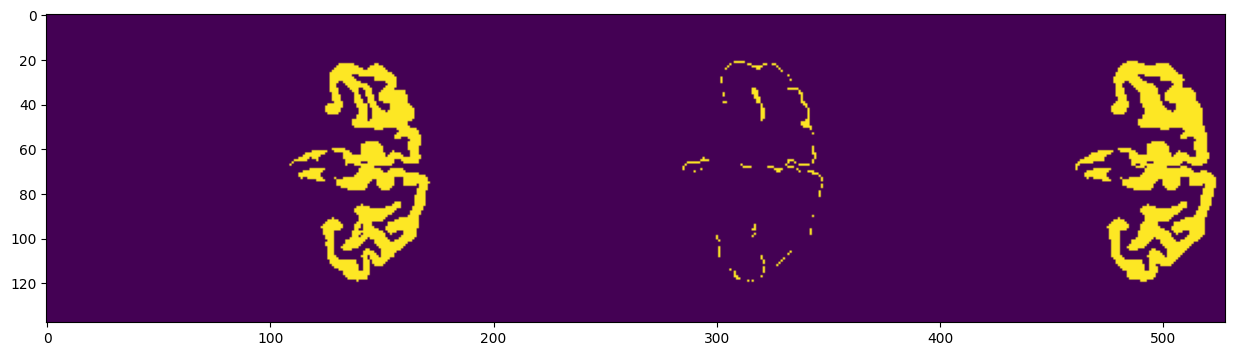

In [70]:
## Show how it look like before and after the mask
increased_voxels_in_csf_notin_wm, new_mask = modify_mask(smask_parc,frontal_index, frontal_mask, csf_mask, wm_mask, threshold_fr)
# save the mask
new_mask_apdding = np.zeros((160, 192, 157))
new_mask_apdding[11:11+138,8:8+176,9:9+138] = new_mask
nib.save(nib.Nifti1Image(new_mask_apdding, affine=np.eye(4)), '/scratch/m000065/binxu/gcp/binxu/wepeng/binxu/binx/test_masks/new_front_mask.nii.gz')
new_mask_apdding = np.zeros((160, 192, 157))
new_mask_apdding[11:11+138,8:8+176,9:9+138] = frontal_mask
nib.save(nib.Nifti1Image(new_mask_apdding, affine=np.eye(4)), '/scratch/m000065/binxu/gcp/binxu/wepeng/binxu/binx/test_masks/front_mask.nii.gz')
# visualization
#concat and plot the insular_probs
combined_mask = np.concatenate((frontal_mask[:,:,64], increased_voxels_in_csf_notin_wm[:,:,64], new_mask[:,:,64]), axis=-1)
plt.figure(figsize=(20, 4))
plt.imshow(combined_mask)

## You can at most increase 2%

Increase: 20.16367216342604%


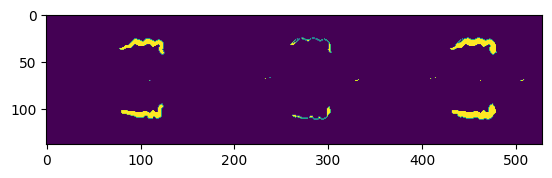

In [30]:
## Show how it look like before and after the mask
increased_voxels_in_csf_notin_wm, new_mask = modify_mask(smask_parc,insular_index, insular_mask, csf_mask, wm_mask, threshold_in)
# visualization
#concat and plot the insular_probs
combined_mask = np.concatenate((insular_mask[:,:,66], increased_voxels_in_csf_notin_wm[:,:,66], new_mask[:,:,66]), axis=-1)
plt.imshow(combined_mask)

## You can at most increase 9%

Increase: 20.11227882339682%


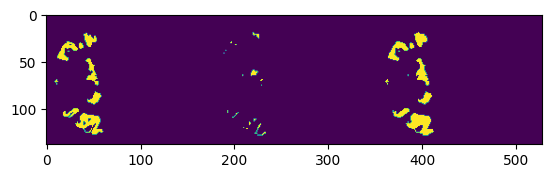

In [31]:
## Show how it look like before and after the mask
increased_voxels_in_csf_notin_wm, new_mask = modify_mask(smask_parc,parietal_index, parietal_mask, csf_mask, wm_mask, threshold_pa)
# visualization
#concat and plot the insular_probs
combined_mask = np.concatenate((parietal_mask[:,:,66], increased_voxels_in_csf_notin_wm[:,:,66], new_mask[:,:,66]), axis=-1)
plt.imshow(combined_mask)

## You can at most increase 2%